# Clustering Assignment: Iris Dataset

Explore K-Means clustering on individual features and all features, and compare with true labels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

### Helper function

In [2]:
def map_clusters_to_labels(preds, y):
    mapped = np.zeros_like(preds)

    for cluster in np.unique(preds):
        mask = preds == cluster
        true_labels = y[mask]

        # Find most common true label in this cluster
        new_label = np.bincount(true_labels).argmax()
        mapped[mask] = new_label

    return mapped

# Loading the dataset

We load and inspect the Iris Dataset

In [3]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Clustering per feature

We define how the clustering is going to be computed for each feature


In [4]:
def plot_feature_clustering(feature_index):
    feature = X[:, feature_index].reshape(-1, 1)

    kmeans = KMeans(n_clusters=3, random_state=42)
    preds = kmeans.fit_predict(feature)
    preds = map_clusters_to_labels(preds, y)

    plt.figure(figsize=(10,4))

    # KMeans clustering
    plt.subplot(1,2,1)
    plt.scatter(range(len(feature)), feature, c=preds, cmap='tab10')
    plt.title(f"KMeans on {feature_names[feature_index]}")

    # True labels
    plt.subplot(1,2,2)
    plt.scatter(range(len(feature)), feature, c=y, cmap='tab10')
    plt.title(f"True labels ({feature_names[feature_index]})")

    plt.show()

# Visualization of results

We compare the labels asigned with the clustering methods against the actual true labels

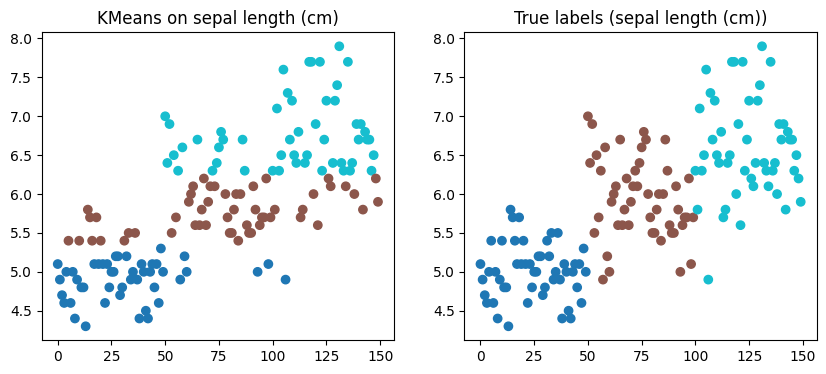

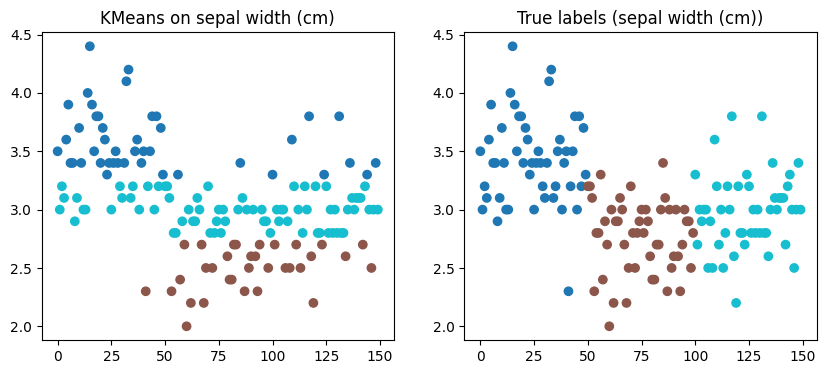

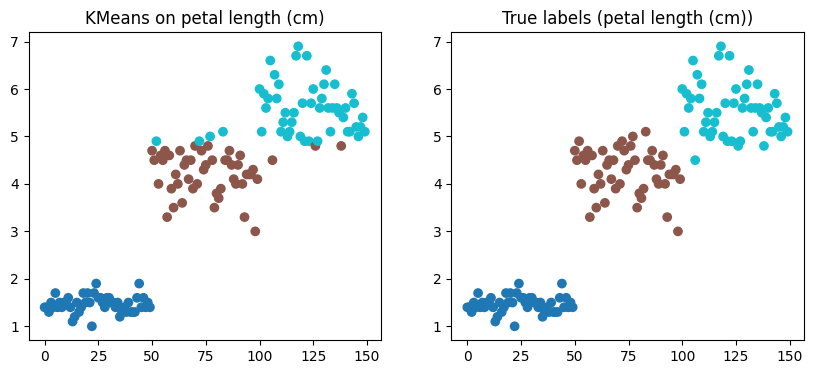

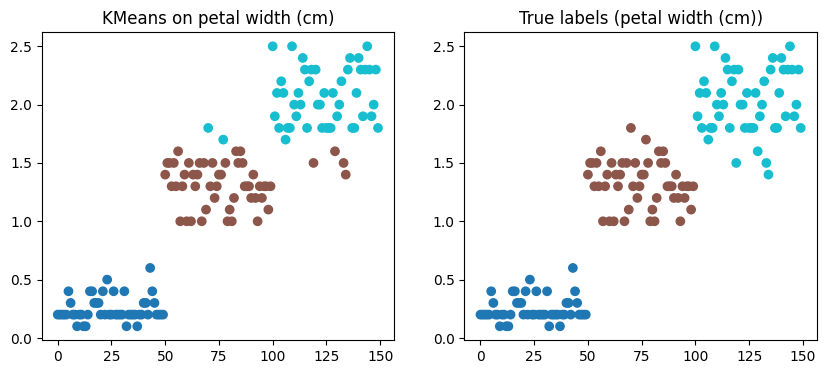

In [5]:
# Apply clustering to each feature
for i in range(X.shape[1]):
    plot_feature_clustering(i)

# Now you!

Perform clustering with the whole dataset, all 4 features, and compare the results.

In your opinion, what approach performs better? Feature-wise clustering or dataset-wise clustering?

In [29]:
kmeans_ds = KMeans(n_clusters=3, random_state=42)
preds_ds = kmeans_ds.fit_predict(X)
preds_ds = map_clusters_to_labels(preds_ds, y)

def plot_feature_clustering_ds(feature_index):
    feature = X[:, feature_index].reshape(-1, 1)

    plt.figure(figsize=(15, 4))

    # KMeans on whole dataset (same labels for all feature plots)
    plt.subplot(1, 3, 1)
    plt.scatter(range(len(feature)), feature, c=preds_ds, cmap='tab10')
    plt.title(f"KMeans on dataset ({feature_names[feature_index]})")

    # True labels
    plt.subplot(1, 3, 2)
    plt.scatter(range(len(feature)), feature, c=y, cmap='tab10')
    plt.title(f"True labels ({feature_names[feature_index]})")

    # KMeans on single feature
    kmeans = KMeans(n_clusters=3, random_state=42)
    preds = kmeans.fit_predict(feature)
    preds = map_clusters_to_labels(preds, y)

    plt.subplot(1, 3, 3)
    plt.scatter(range(len(feature)), feature, c=preds, cmap='tab10')
    plt.title(f"KMeans on {feature_names[feature_index]}")

    plt.show()

    

    plt.show()

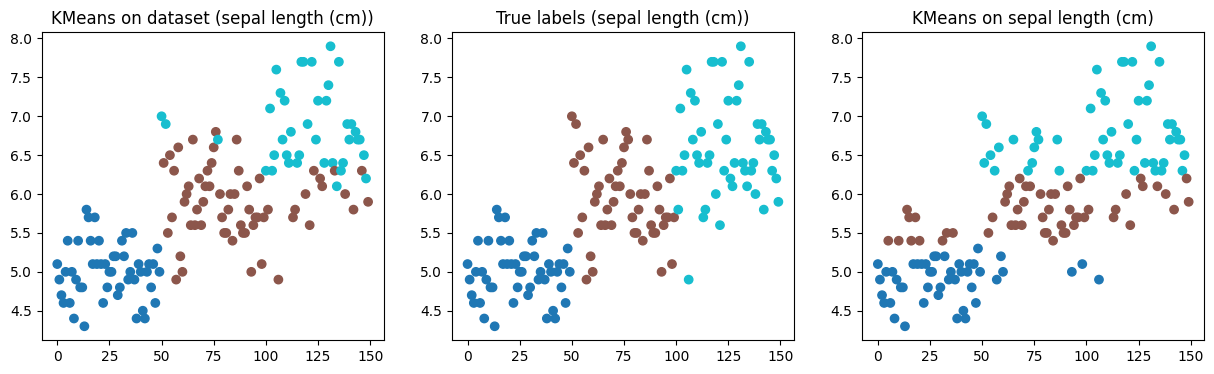

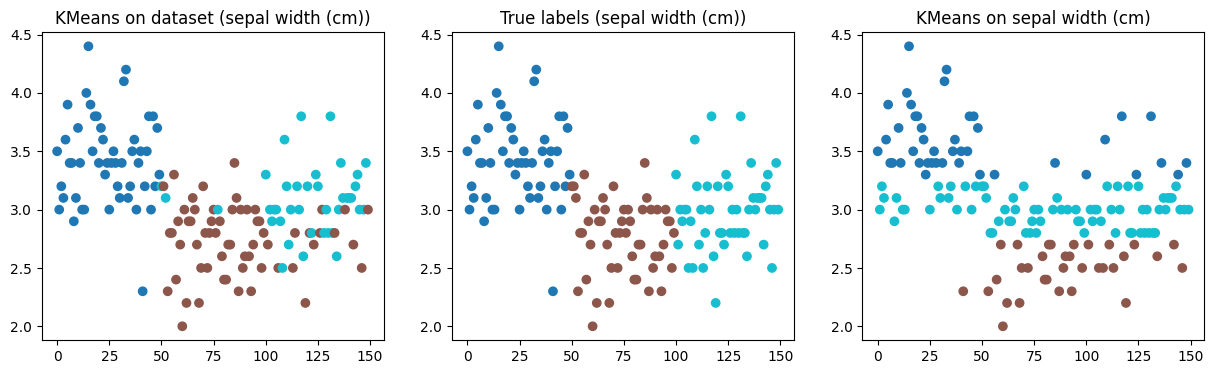

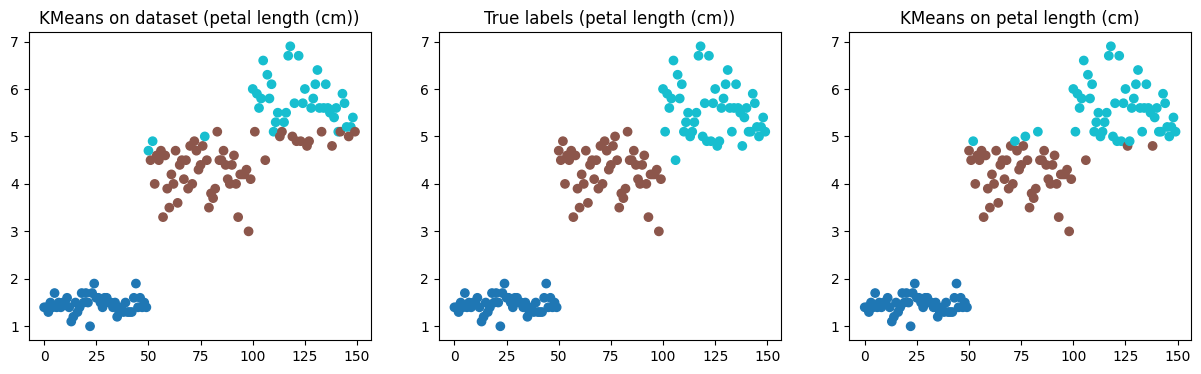

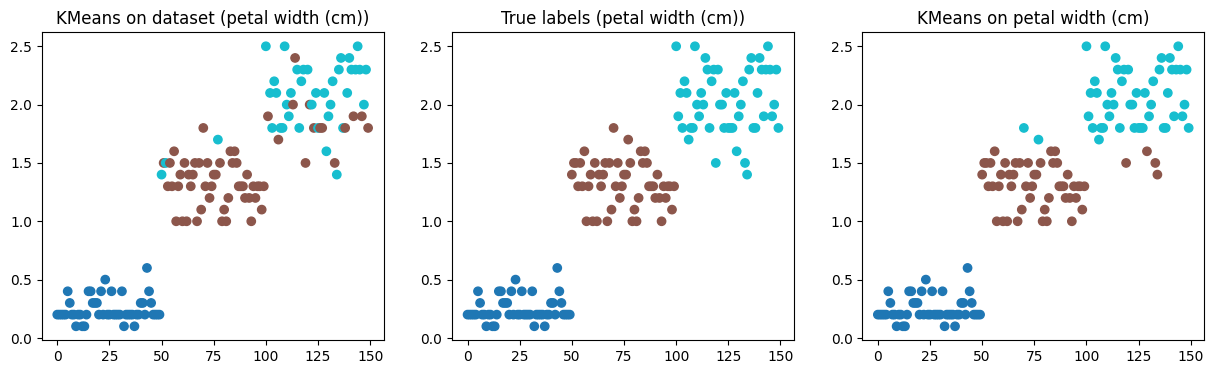

In [30]:
for i in range(X.shape[1]):
    plot_feature_clustering_ds(i)

The plots I have showed are the comparison between actual clusters and the K-Means one. K-Means is applied on the whole cluster just once and then one feature at a time the results are compared with the actual label (middle plot) and feature-wise clustering (right plot). As we can see the plots feature-wise, since they are clustered on a single variable, seem to have longitudinal cuts parallel to the x-axis (so the algorithm chooses a length or width value and cuts there the datasets). So the variables for which the measured value is very relevant show a good performance on feature-wise clustering. But the first two variables (sepal length and sepal width) do not. Generally speaking feature clustering has always the same average error, over all clusters, dataset-wise K-Means gets confuded particularly between brown and light blue clusters. All around dataset-wise clustering seems to work better, even though it has a worst performance on features whose measure is more strongly related to the actual labels (petal length and petal width). Thus I would still choose to apply dataset-wise clustering, it has a good performance overall even though it gets a bit confused, and definetely more confused than the truly significant variables. It will be interesting, since we have the ground truth to compare performance indicators. 